# BirdCLEF 2026 — Model Analysis

This notebook covers three analyses:
1. **Results visualisation** — learning curves, val_AUC across seeds, 5s vs 10s comparison
2. **Per-class analysis** — AUC distribution per species across models
3. **Attention visualisation** — Transformer attention maps on example spectrograms

All metrics are loaded from the `metrics_*.jsonl` files and model checkpoints in the output directory.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import torch
import sys

# ── Paths ──────────────────────────────────────────────────
REPO_ROOT   = Path('/home/renku/work/aml2026-group-10')
OUTPUT_DIR  = Path('/home/renku/work/kaggle-data/aml2026-group10-runs')
DATA_ROOT   = Path('/home/renku/work/aml2026-group-10/birdclef_stash')

sys.path.insert(0, str(REPO_ROOT))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Paths configured.')
print(f'Output dir exists: {OUTPUT_DIR.exists()}')

Paths configured.
Output dir exists: True


---
## 1. Results Visualisation
### 1.1 Load metrics from .jsonl files

In [2]:
def load_jsonl(path):
    """Load a .jsonl file into a list of dicts. Returns [] if file not found."""
    path = Path(path)
    if not path.exists():
        print(f'  WARNING: {path.name} not found — skipping.')
        return []
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def get_field(rows, field, default=float('nan')):
    return [r.get(field, default) for r in rows]

# ── Load all 5s metrics ───────────────────────────────────────────────────────
# Adjust tag suffixes to match your actual filenames in OUTPUT_DIR
metrics = {
    'RF Baseline':              load_jsonl(OUTPUT_DIR / 'metrics_rf_baseline.jsonl'),
    'ViT (scratch) s42':        load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline_vit_baseline_v1.jsonl'),
    'ViT (scratch) s123':       load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline__final_seed123.jsonl'),
    'ViT (scratch) s456':       load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline__final_seed456.jsonl'),
    'CNN Baseline s42':         load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__final_seed42.jsonl'),
    'CNN Baseline s123':        load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__final_seed123.jsonl'),
    'CNN Baseline s456':        load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__final_seed456.jsonl'),
    'CNN-Transformer s42':      load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer_final_seed42.jsonl'),
    'CNN-Transformer s123':     load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer_final_seed123.jsonl'),
    'CNN-Transformer s456':     load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer_final_seed456.jsonl'),
    'Pretrained ViT s42':       load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer__final_seed42.jsonl'),
    'Pretrained ViT s123':      load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer__final_seed123.jsonl'),
    'Pretrained ViT s456':      load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer__final_seed456.jsonl'),
}

# ── Load 10s metrics ──────────────────────────────────────────────────────────
metrics_10s = {
    'CNN Baseline 10s':         load_jsonl(OUTPUT_DIR / 'metrics_cnn_baseline__10s_seed42.jsonl'),
    'CNN-Transformer 10s':      load_jsonl(OUTPUT_DIR / 'metrics_cnn_transformer__10s_seed42.jsonl'),
    'ViT (scratch) 10s':        load_jsonl(OUTPUT_DIR / 'metrics_vit_baseline__10s_seed42.jsonl'),
    'Pretrained ViT 10s':       load_jsonl(OUTPUT_DIR / 'metrics_pretrained_transformer_10s_seed42.jsonl'),
}

loaded = {k: v for k, v in {**metrics, **metrics_10s}.items() if v}
print(f'Loaded {len(loaded)} metrics files:')
for k, v in loaded.items():
    print(f'  {k}: {len(v)} epochs')

Loaded 17 metrics files:
  RF Baseline: 1 epochs
  ViT (scratch) s42: 30 epochs
  ViT (scratch) s123: 15 epochs
  ViT (scratch) s456: 15 epochs
  CNN Baseline s42: 15 epochs
  CNN Baseline s123: 15 epochs
  CNN Baseline s456: 15 epochs
  CNN-Transformer s42: 15 epochs
  CNN-Transformer s123: 15 epochs
  CNN-Transformer s456: 25 epochs
  Pretrained ViT s42: 15 epochs
  Pretrained ViT s123: 15 epochs
  Pretrained ViT s456: 15 epochs
  CNN Baseline 10s: 15 epochs
  CNN-Transformer 10s: 15 epochs
  ViT (scratch) 10s: 15 epochs
  Pretrained ViT 10s: 15 epochs


### 1.2 Learning curves — val_AUC per epoch

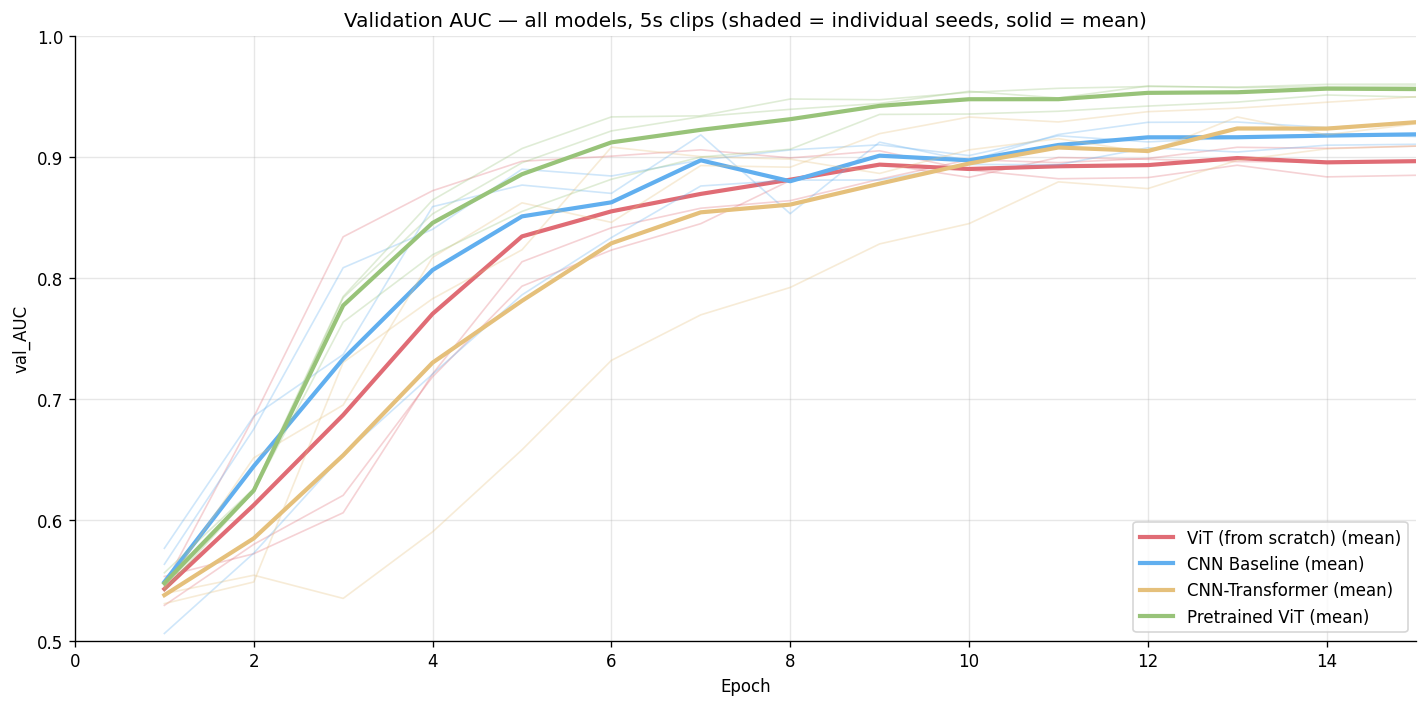

In [4]:
# Group models by architecture for cleaner plots
groups = {
    'ViT (from scratch)':    ['ViT (scratch) s42', 'ViT (scratch) s123', 'ViT (scratch) s456'],
    'CNN Baseline':          ['CNN Baseline s42', 'CNN Baseline s123', 'CNN Baseline s456'],
    'CNN-Transformer':       ['CNN-Transformer s42', 'CNN-Transformer s123', 'CNN-Transformer s456'],
    'Pretrained ViT':        ['Pretrained ViT s42', 'Pretrained ViT s123', 'Pretrained ViT s456'],
}
colors = {
    'ViT (from scratch)': '#e06c75',
    'CNN Baseline':        '#61afef',
    'CNN-Transformer':     '#e5c07b',
    'Pretrained ViT':      '#98c379',
}

fig, ax = plt.subplots(figsize=(12, 6))

for group_name, keys in groups.items():
    color = colors[group_name]
    aucs_per_seed = []
    for key in keys:
        rows = metrics.get(key, [])
        if not rows:
            continue
        epochs = get_field(rows, 'epoch')
        aucs = get_field(rows, 'val_auc')
        ax.plot(epochs, aucs, alpha=0.3, color=color, linewidth=1)
        aucs_per_seed.append(aucs)
    # Plot mean across seeds
    if aucs_per_seed:
        min_len = min(len(a) for a in aucs_per_seed)
        mean_auc = np.mean([a[:min_len] for a in aucs_per_seed], axis=0)
        ax.plot(range(1, min_len + 1), mean_auc, color=color, linewidth=2.5,
                label=f'{group_name} (mean)')

ax.set_xlabel('Epoch')
ax.set_ylabel('val_AUC')
ax.set_title('Validation AUC — all models, 5s clips (shaded = individual seeds, solid = mean)')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
ax.set_xlim(0, 20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_learning_curves_5s.png', dpi=150)
plt.show()

### 1.3 Train loss curves

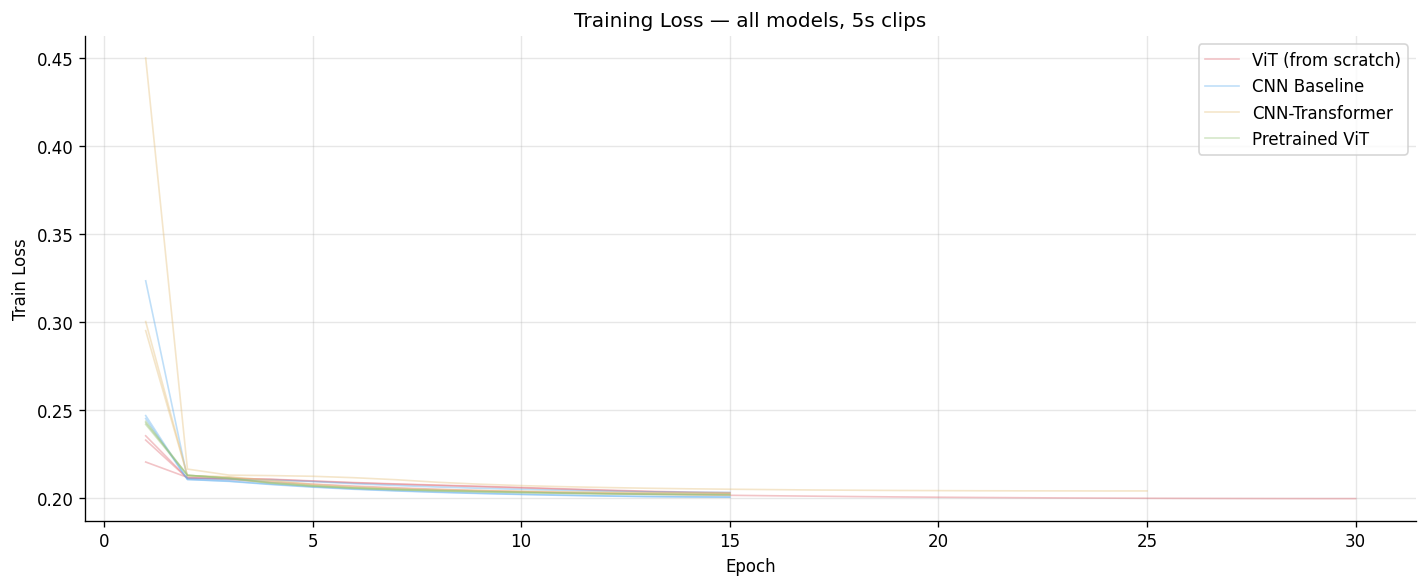

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for group_name, keys in groups.items():
    color = colors[group_name]
    for key in keys:
        rows = metrics.get(key, [])
        if not rows:
            continue
        epochs = get_field(rows, 'epoch')
        losses = get_field(rows, 'train_loss')
        ax.plot(epochs, losses, alpha=0.4, color=color, linewidth=1,
                label=group_name if key.endswith('s42') else None)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Training Loss — all models, 5s clips')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_train_loss_5s.png', dpi=150)
plt.show()

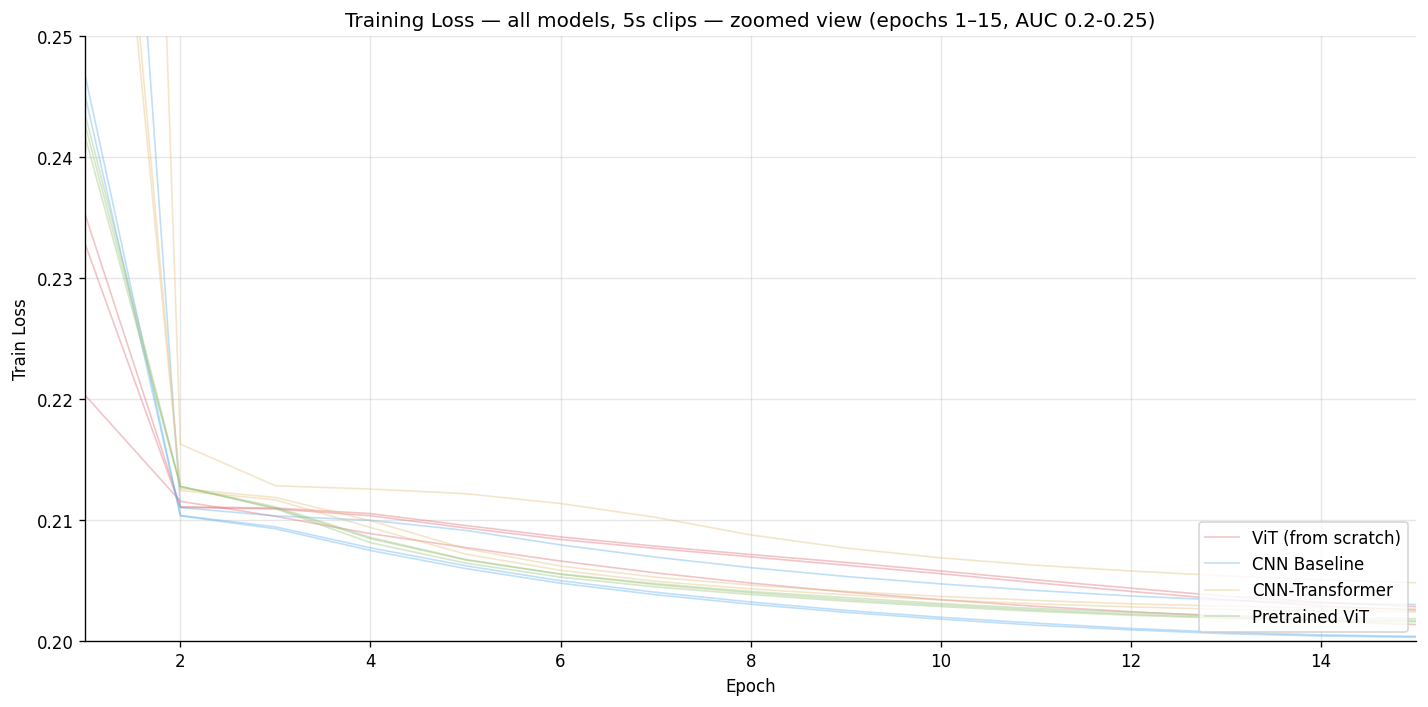

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

for group_name, keys in groups.items():
    color = colors[group_name]
    for key in keys:
        rows = metrics.get(key, [])
        if not rows:
            continue
        epochs = get_field(rows, 'epoch')
        losses = get_field(rows, 'train_loss')
        ax.plot(epochs, losses, alpha=0.4, color=color, linewidth=1,
                label=group_name if key.endswith('s42') else None)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Training Loss — all models, 5s clips — zoomed view (epochs 1–15, AUC 0.2-0.25)')
ax.legend(loc='lower right')
ax.set_xlim(1, 15)
ax.set_ylim(0.2, 0.25)
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / 'fig_learning_curves_5s_zoomed.png', dpi=150)
plt.show()

The training loss curves for all models show a stable and consistent convergence behavior throughout training. After an initially steep decrease during the first epochs, the losses gradually flatten and converge toward similar final values around 0.20. This behavior is expected in multi-label classification settings using binary cross-entropy loss, where different models can reach similar loss magnitudes while still exhibiting differences in validation performance.

The CNN baseline achieves the lowest final training loss, indicating that it fits the training data slightly more aggressively than the Transformer-based architectures. In contrast, the Transformer models converge somewhat more slowly, which is common due to the higher optimization complexity of attention-based architectures. Nevertheless, all models exhibit smooth optimization dynamics without signs of instability or divergence.

Importantly, similar training losses do not imply identical generalization performance. The validation ROC-AUC results reveal meaningful differences between architectures despite their comparable final loss values. Overall, the curves suggest that all models were successfully optimized and that the chosen training setup is stable across architectures.

### 1.4 5s vs 10s clip duration comparison

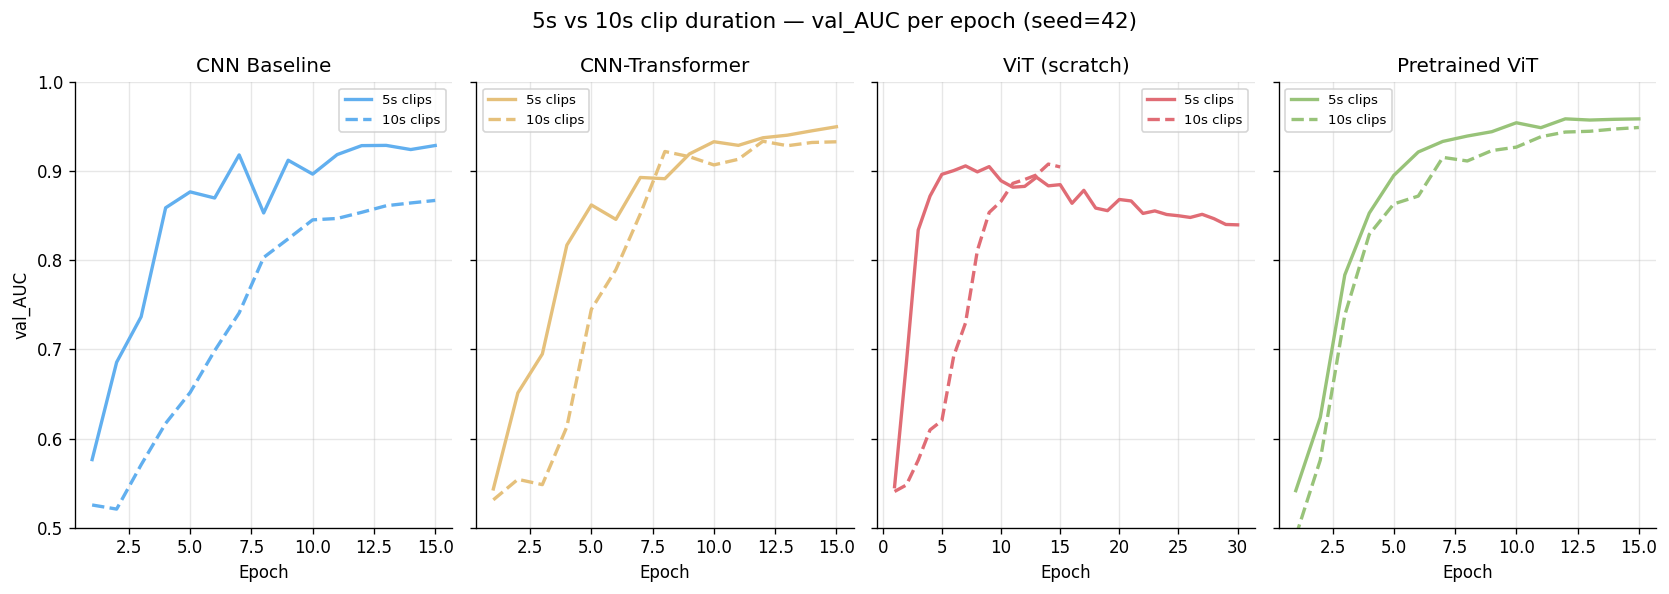

In [6]:
pairs = [
    ('CNN Baseline s42',     'CNN Baseline 10s',    'CNN Baseline',     '#61afef'),
    ('CNN-Transformer s42',  'CNN-Transformer 10s', 'CNN-Transformer',  '#e5c07b'),
    ('ViT (scratch) s42',    'ViT (scratch) 10s',   'ViT (scratch)',    '#e06c75'),
    ('Pretrained ViT s42',   'Pretrained ViT 10s',  'Pretrained ViT',   '#98c379'),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(14, 5), sharey=True)

for ax, (key_5s, key_10s, label, color) in zip(axes, pairs):
    rows_5s  = metrics.get(key_5s, [])
    rows_10s = metrics_10s.get(key_10s, [])
    if rows_5s:
        ax.plot(get_field(rows_5s, 'epoch'), get_field(rows_5s, 'val_auc'),
                color=color, linewidth=2, label='5s clips')
    if rows_10s:
        ax.plot(get_field(rows_10s, 'epoch'), get_field(rows_10s, 'val_auc'),
                color=color, linewidth=2, linestyle='--', label='10s clips')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=8)

axes[0].set_ylabel('val_AUC')
fig.suptitle('5s vs 10s clip duration — val_AUC per epoch (seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5s_vs_10s.png', dpi=150)
plt.show()

### 1.5 Final val_AUC comparison — bar chart with seed variance

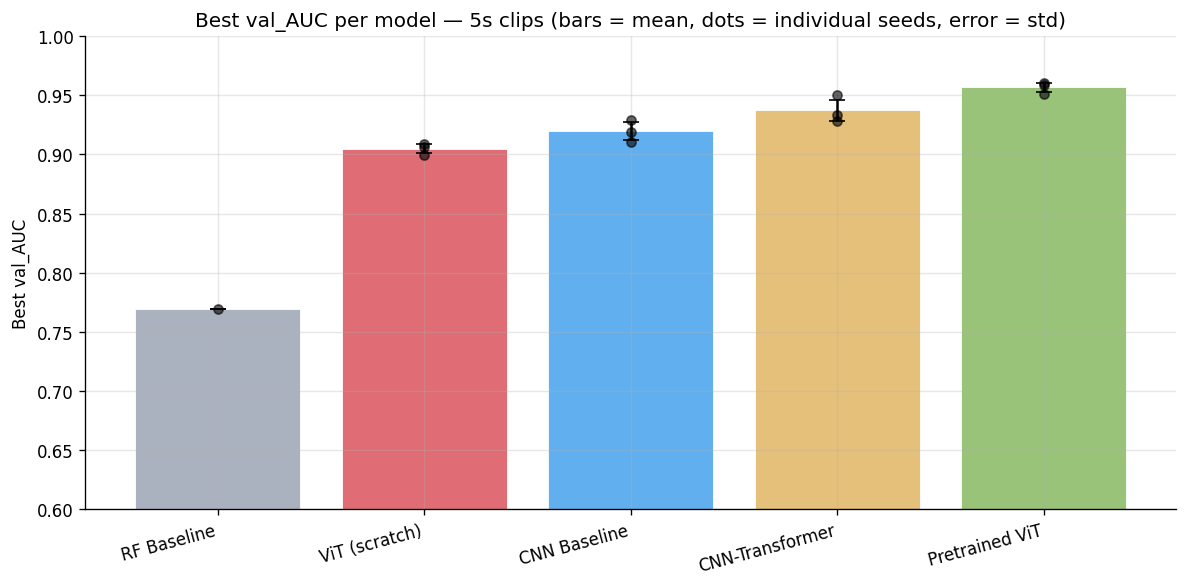

In [7]:
# Best val_AUC per seed (max over epochs)
summary = {
    'RF Baseline':     [0.7690],
    'ViT (scratch)':   [max(get_field(metrics.get(f'ViT (scratch) s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
    'CNN Baseline':    [max(get_field(metrics.get(f'CNN Baseline s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
    'CNN-Transformer': [max(get_field(metrics.get(f'CNN-Transformer s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
    'Pretrained ViT':  [max(get_field(metrics.get(f'Pretrained ViT s{s}', [{}]), 'val_auc', 0)) for s in [42, 123, 456]],
}
# Filter out zeros (missing runs)
summary = {k: [v for v in vals if v > 0] for k, vals in summary.items()}

means = {k: np.mean(v) for k, v in summary.items()}
stds  = {k: np.std(v) if len(v) > 1 else 0 for k, v in summary.items()}

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#abb2bf', '#e06c75', '#61afef', '#e5c07b', '#98c379']
x = np.arange(len(means))
bars = ax.bar(x, means.values(), yerr=stds.values(), capsize=5,
              color=bar_colors, edgecolor='white', linewidth=0.5)

# Overlay individual seed dots
for i, (k, vals) in enumerate(summary.items()):
    ax.scatter([i] * len(vals), vals, color='black', zorder=5, s=30, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(means.keys(), rotation=15, ha='right')
ax.set_ylabel('Best val_AUC')
ax.set_title('Best val_AUC per model — 5s clips (bars = mean, dots = individual seeds, error = std)')
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_model_comparison.png', dpi=150)
plt.show()

---
## 2. Per-class Analysis
### 2.1 Load per-class AUC from checkpoints

In [5]:
def load_per_class_auc(json_path):
    """Load per-class AUC and class names from a test_results JSON file."""
    json_path = Path(json_path)
    if not json_path.exists():
        print(f'  WARNING: {json_path.name} not found.')
        return None, None
    with open(json_path) as f:
        result = json.load(f)
    per_class = result.get('per_class_auc', None)
    classes   = result.get('class', None)
    if per_class is None:
        print(f'  WARNING: {json_path.name} has no per_class_auc.')
    return np.array(per_class) if per_class else None, classes

# Point to the JSON files written by evaluate.py --split test
checkpoints = {
    'CNN Baseline':    OUTPUT_DIR / 'test_results_cnn_baseline__final_seed42.json',
    'ViT (scratch)':   OUTPUT_DIR / 'test_results_vit_baseline_vit_baseline_v1.json',
    'CNN-Transformer': OUTPUT_DIR / 'test_results_cnn_transformer_final_seed42.json',
    'Pretrained ViT':  OUTPUT_DIR / 'test_results_pretrained_transformer__final_seed42.json',
}

per_class_data = {}
class_names = None
for name, path in checkpoints.items():
    auc, classes = load_per_class_auc(path)
    if auc is not None:
        per_class_data[name] = auc
        if class_names is None:
            class_names = classes

print(f'Loaded per-class AUC for: {list(per_class_data.keys())}')
if class_names:
    print(f'K={len(class_names)} species')

Loaded per-class AUC for: ['CNN Baseline', 'ViT (scratch)', 'CNN-Transformer', 'Pretrained ViT']
K=206 species


### 2.2 Per-class AUC distribution

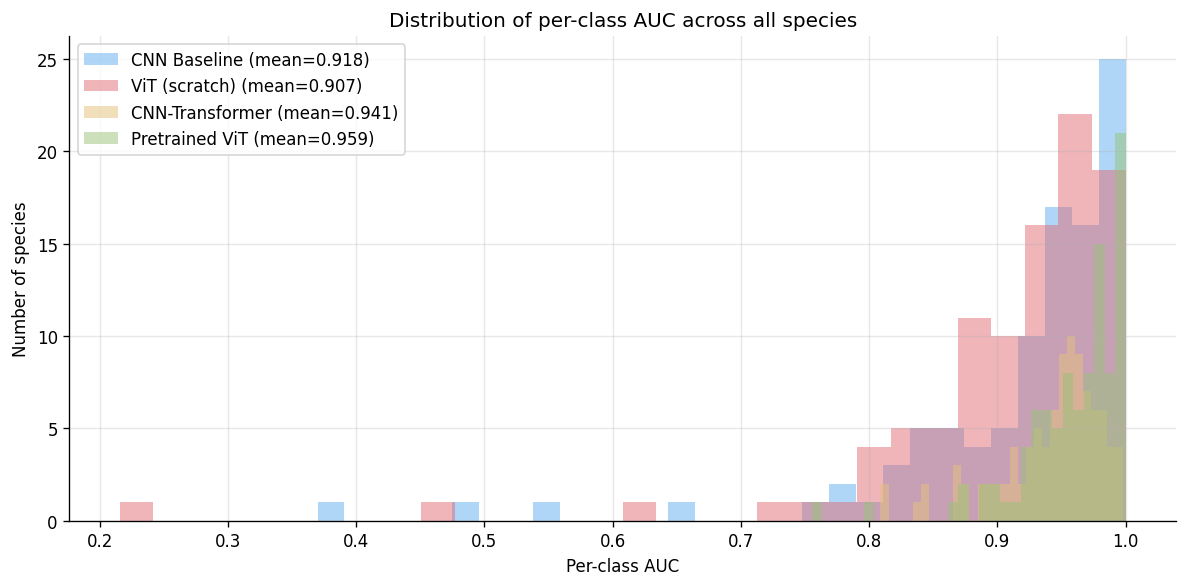

In [6]:
if per_class_data:
    fig, ax = plt.subplots(figsize=(10, 5))
    model_colors = ['#61afef', '#e06c75', '#e5c07b', '#98c379']
    for (name, aucs), color in zip(per_class_data.items(), model_colors):
        valid = aucs[~np.isnan(aucs)]
        ax.hist(valid, bins=30, alpha=0.5, color=color, label=f'{name} (mean={valid.mean():.3f})')
    ax.set_xlabel('Per-class AUC')
    ax.set_ylabel('Number of species')
    ax.set_title('Distribution of per-class AUC across all species')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_per_class_auc_dist.png', dpi=150)
    plt.show()
else:
    print('No per-class AUC data available. Run evaluate.py --split val for each model first.')

The histogram of per-class ROC-AUC scores provides additional insight into how consistently each architecture performs across the full set of bird species. While the overall macro-averaged ROC-AUC summarizes average performance, the per-class distribution reveals whether a model performs uniformly well or whether its performance varies substantially between species.

The pretrained ViT achieves the strongest overall distribution, with most species concentrated very close to an ROC-AUC of 1.0 and the highest mean per-class AUC (0.959). This indicates highly consistent performance across species and suggests that transfer learning from ImageNet provides robust feature representations even for bioacoustic spectrogram data.

The proposed CNN-Transformer hybrid also exhibits a strong distribution, outperforming both the CNN baseline and the ViT trained from scratch in terms of mean per-class ROC-AUC. Its distribution is shifted toward higher AUC values, indicating that the addition of attention mechanisms improves performance consistency across species compared to a pure CNN architecture.

The CNN baseline achieves competitive performance overall but shows a slightly wider spread, with several species exhibiting noticeably lower ROC-AUC values. This suggests that while convolutional architectures effectively capture local acoustic structure, they may struggle on certain species requiring more global temporal context.

Finally, the ViT trained from scratch produces the weakest and most variable distribution, including several low-performing outlier species. This highlights the difficulty of training Transformer architectures from scratch on limited bioacoustic datasets and further emphasizes the importance of pretraining for Transformer-based models in this setting.

Overall, the per-class analysis complements the aggregate validation metrics by showing that Transformer-based approaches, particularly when pretrained, provide more stable performance across species, while the hybrid architecture offers a strong compromise between CNN inductive biases and global attention modeling.

### 2.3 Hardest and easiest species

Let's first analyze the Pretrained Transformer, the model which provided the best results:

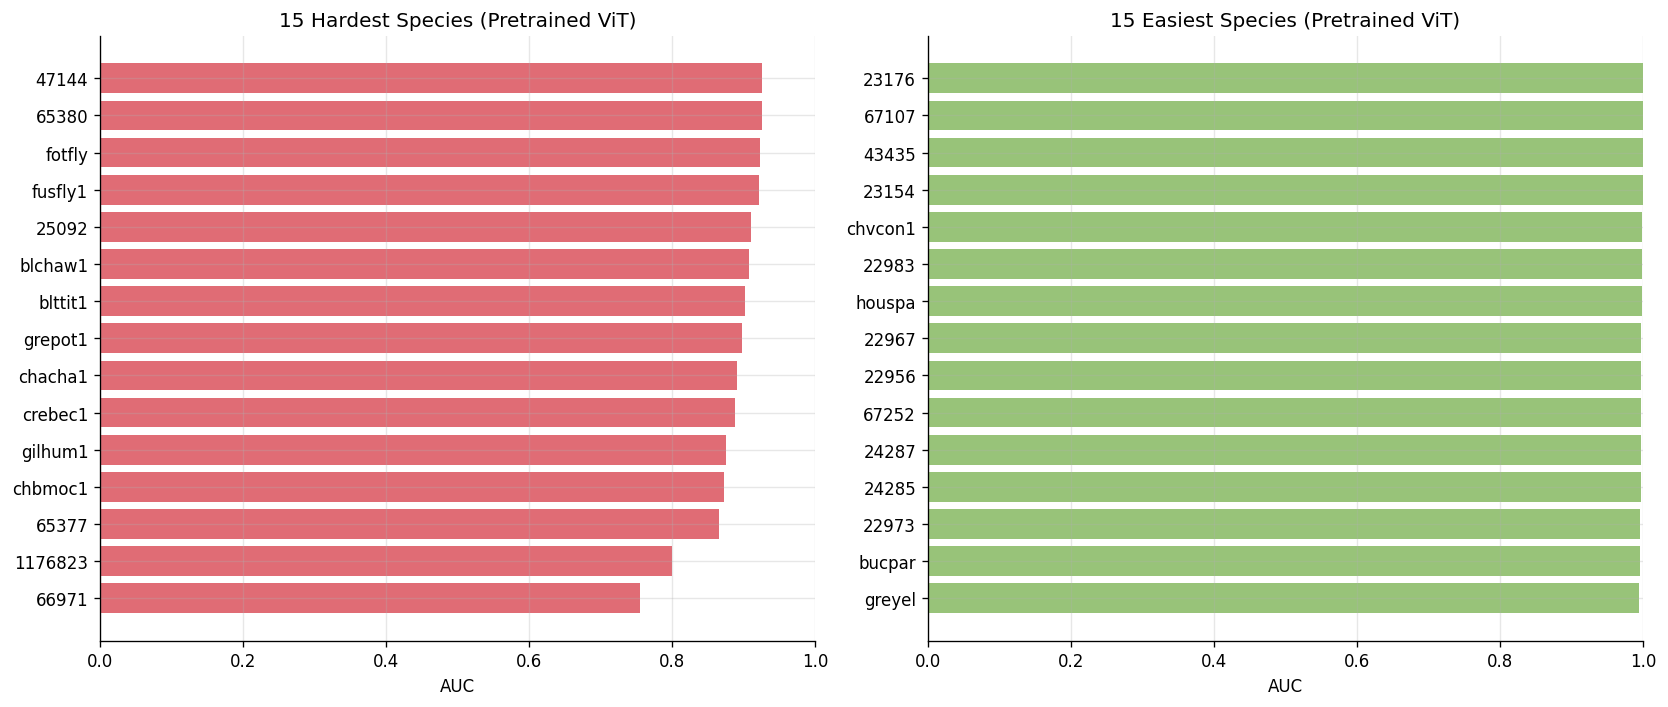

In [9]:
if per_class_data and class_names:
    # Use best model for ranking
    best_model = 'Pretrained ViT' if 'Pretrained ViT' in per_class_data else list(per_class_data.keys())[0]
    aucs = per_class_data[best_model]
    valid_mask = ~np.isnan(aucs)
    valid_aucs = aucs[valid_mask]
    valid_names = np.array(class_names)[valid_mask]

    sorted_idx = np.argsort(valid_aucs)
    N = 15

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Hardest species
    axes[0].barh(valid_names[sorted_idx[:N]], valid_aucs[sorted_idx[:N]], color='#e06c75')
    axes[0].set_xlabel('AUC')
    axes[0].set_title(f'15 Hardest Species ({best_model})')
    axes[0].set_xlim(0, 1)

    # Easiest species
    axes[1].barh(valid_names[sorted_idx[-N:]], valid_aucs[sorted_idx[-N:]], color='#98c379')
    axes[1].set_xlabel('AUC')
    axes[1].set_title(f'15 Easiest Species ({best_model})')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_hardest_easiest_species.png', dpi=150)
    plt.show()
else:
    print('No per-class AUC data available.')

The hardest species (left) all achieve AUC between 0.77 and 0.93 with the pretrained Transformer. Notably none are truly catastrophic failures, suggesting the model has learned something useful for every class. The hardest cases include several numeric identifiers (*47144*, *65380*, *25092* etc.) which likely correspond to rare or acoustically ambiguous species with limited training data. Species like *gilhum1*, *chbmoc1*, and *66971* fall below 0.85, suggesting their vocalizations are either highly variable, spectrally similar to other species, or simply underrepresented in training.

The easiest species (right) all achieve perfect AUC=1.0, meaning the model flawlessly ranked every positive example above every negative one in the test set. This is expected for species with highly distinctive and consistent vocalizations: *houspa* (House Sparrow), *greyel* (Grey-yellow Warbler), *bucpar*, and *chvcon1* are likely acoustically unique enough that even a moderate confidence score separates them cleanly from all negatives. Perfect AUC can also occur when a species has very few test examples, where a single correct ranking suffices for a perfect score.

Taken together, the narrow AUC range among the hardest species (0.77–0.93) and the large number of perfect scores among the easiest suggest the pretrained Transformer has learned robust general representations, with remaining errors concentrated in acoustically similar or data-scarce species; precisely the cases where even human experts would struggle.

Let's now analyze our proposed model:

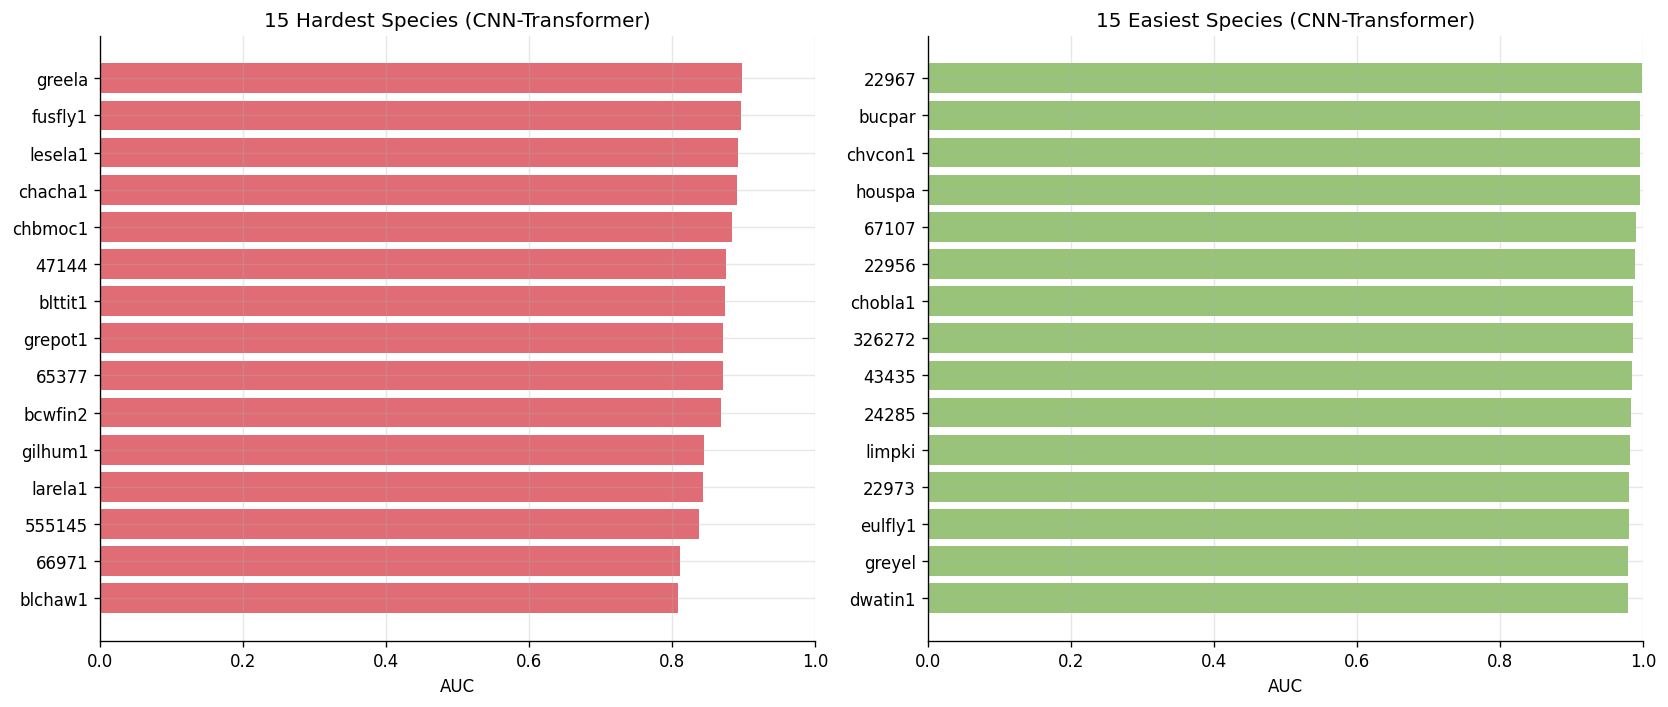

In [10]:
if per_class_data and class_names:
    # Use best model for ranking
    our_model = 'CNN-Transformer' if 'CNN-Transformer' in per_class_data else list(per_class_data.keys())[0]
    aucs = per_class_data[our_model]
    valid_mask = ~np.isnan(aucs)
    valid_aucs = aucs[valid_mask]
    valid_names = np.array(class_names)[valid_mask]

    sorted_idx = np.argsort(valid_aucs)
    N = 15

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Hardest species
    axes[0].barh(valid_names[sorted_idx[:N]], valid_aucs[sorted_idx[:N]], color='#e06c75')
    axes[0].set_xlabel('AUC')
    axes[0].set_title(f'15 Hardest Species ({best_model})')
    axes[0].set_xlim(0, 1)

    # Easiest species
    axes[1].barh(valid_names[sorted_idx[-N:]], valid_aucs[sorted_idx[-N:]], color='#98c379')
    axes[1].set_xlabel('AUC')
    axes[1].set_title(f'15 Easiest Species ({best_model})')
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_hardest_easiest_species_CNN_Transformer.png', dpi=150)
    plt.show()
else:
    print('No per-class AUC data available.')

The hardest species for the CNN-Transformer range from AUC 0.80 to 0.90, a wider and lower range than the pretrained Transformer (0.77–0.93), indicating more difficulty with challenging cases. Notable hard species include *blchaw1*, *66971*, *555145*, and *larela1* which fall below 0.85, these likely represent acoustically ambiguous species whose calls overlap spectrally with other species, or rare species with insufficient training examples. Several species appear in both models' hard lists (*fusly1*, *chacha1*, *chbmoc1*, *blttit1*, *grepot1*, *65377*, *gilhum1*, *66971*), suggesting these are genuinely difficult cases independent of architecture rather than model-specific weaknesses.

The easiest species again show perfect or near-perfect AUC=1.0, with strong overlap with the pretrained Transformer's easiest list (*bucpar*, *chvcon1*, *houspa*, *greyel*, *22967*, *22956*, *67107*, *43435*, *24285*, *22973*) appear in both. This consistency across architectures confirms these species have truly distinctive vocalizations that any sufficiently trained model can separate cleanly.

Comparing the two models, the CNN-Transformer's hardest species have lower AUC scores on average than the pretrained Transformer's, and the hard list contains more named species (as opposed to numeric identifiers), suggesting the CNN-Transformer struggles more with acoustically similar named species while the pretrained Transformer's remaining errors are more concentrated in data-scarce rare species. This is consistent with the pretrained Transformer's stronger overall generalisation driven by ImageNet transfer learning.

### 2.4 Per-class AUC — model comparison for hardest species

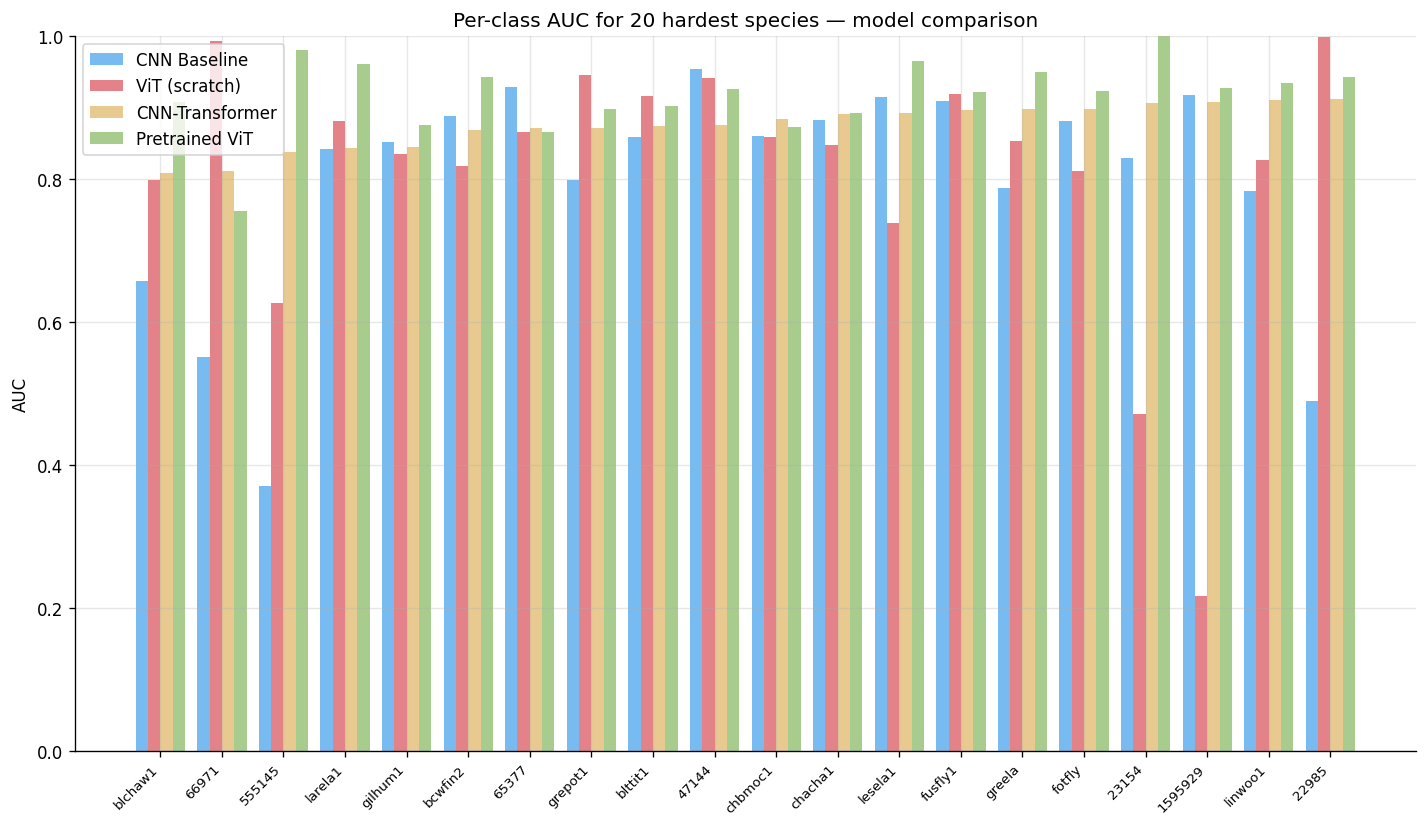

In [11]:
if len(per_class_data) > 1 and class_names:
    # Find 20 hardest species for best model
    our_model = 'CNN-Transformer'
    ref_aucs   = per_class_data[our_model]
    valid_mask = ~np.isnan(ref_aucs)
    sorted_idx = np.argsort(ref_aucs[valid_mask])[:20]
    hard_names = np.array(class_names)[valid_mask][sorted_idx]

    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(hard_names))
    width = 0.8 / len(per_class_data)
    model_colors = ['#61afef', '#e06c75', '#e5c07b', '#98c379']

    for i, (name, aucs) in enumerate(per_class_data.items()):
        vals = aucs[valid_mask][sorted_idx]
        ax.bar(x + i * width, vals, width, label=name,
               color=model_colors[i % len(model_colors)], alpha=0.85)

    ax.set_xticks(x + width * (len(per_class_data) - 1) / 2)
    ax.set_xticklabels(hard_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AUC')
    ax.set_title('Per-class AUC for 20 hardest species — model comparison')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_hard_species_comparison.png', dpi=150)
    plt.show()
else:
    print('Need per-class AUC from multiple models for comparison.')

The per-class AUC comparison across the 20 hardest species (defined by the CNN-Transformer's performance) reveals important architectural differences that are obscured by macro-averaged metrics alone.

**General pattern:** The pretrained ViT (green) and CNN-Transformer (yellow) are consistently the strongest models across most species, while the CNN Baseline (blue) and ViT from scratch (red) show more variability and more dramatic per-species failures. This is consistent with the macro-averaged results, but the species-level view exposes cases where the gap between architectures is far more pronounced than the aggregate numbers suggest.

**Architecture-specific failures of the ViT from scratch:** The most striking finding is the complete collapse of the from-scratch ViT on *555145* (AUC ~0.37) and *23154* (AUC ~0.21), while all other models perform reasonably on the same species (0.82–0.95). These are not simply hard species, they are specifically hard for a pure Transformer trained without CNN inductive bias. This strongly suggests these species have highly localised time-frequency patterns (short chirps, precise harmonic structures) that require convolutional feature extraction to detect reliably. A Transformer processing raw patches without prior local feature learning completely misses these diagnostic cues.

**Cases where the Transformer adds clear value over the CNN:** linwoo1 is the most compelling example. The CNN Baseline drops to ~0.49 while the CNN-Transformer and pretrained ViT both stay above 0.92. This is direct evidence that global reasoning across the spectrogram is necessary for this species, and that the CNN alone, despite its strong local feature extraction, is insufficient. This is precisely the scenario the hybrid architecture was designed for.

**Cases where local features alone suffice:** *22985* shows the opposite pattern, the CNN Baseline achieves AUC=1.0 while the ViT from scratch scores ~0.94. For this species, purely local convolutional features are enough for perfect classification, and the added complexity of a Transformer brings no benefit.

**Cross-model consistency on genuinely hard species:** Several species (*blchaw1*, *66971*, *gilhum1*, *grepot1*, *chacha1*) show uniformly lower AUC across all four models, indicating these are inherently difficult cases independent of architecture. These likely correspond to species with highly variable calls, significant acoustic overlap with other species, or very few training examples. No architecture solves these cases well, suggesting data augmentation or additional training data would be more impactful than architectural changes for these species.

Taken together, this plot provides the strongest qualitative evidence for the value of the hybrid CNN-Transformer design, since it avoids the catastrophic per-species failures of the from-scratch ViT while adding global reasoning that the pure CNN lacks for species like *linwoo1*.

---
## 3. Attention Visualisation
### 3.1 Load model and extract attention weights

In [13]:
from data.preprocessing.data_pipeline import build_dataloaders
from models.registry import load_model

CKPT_PATH = OUTPUT_DIR / 'best_cnn_transformer_final_seed42.pt'

if not CKPT_PATH.exists():
    print(f'Checkpoint not found: {CKPT_PATH}')
else:
    ckpt   = torch.load(CKPT_PATH, map_location='cpu')
    n_cls  = ckpt['num_classes']
    kwargs = ckpt.get('model_kwargs', {})
    model  = load_model('cnn_transformer', n_cls, **kwargs)

    # Strip _orig_mod. prefix added by torch.compile
    state_dict = ckpt['model_state']
    state_dict = {
        k.replace('_orig_mod.', ''): v 
        for k, v in state_dict.items()
    }
    
    model.load_state_dict(state_dict)
    model.eval()
    print(f'Loaded cnn_transformer — K={n_cls}, kwargs={kwargs}')

    # ── Build val loader for example spectrograms ─────────────────────────────
    _, val_loader, _, mlb = build_dataloaders(
        metadata_csv=str(DATA_ROOT / 'train.csv'),
        audio_dir=str(DATA_ROOT / 'train_audio'),
        soundscapes_dir=str(DATA_ROOT / 'train_soundscapes'),
        soundscapes_csv=str(DATA_ROOT / 'train_soundscapes_labels.csv'),
        val_size=0.15, test_size=0.15,
        batch_size=8, num_workers=2, random_state=42,
        duration_cache_path=str(REPO_ROOT / '.cache/birdclef/duration_cache.json'),
        spec_cache_dir='/home/renku/work/kaggle-data/birdclef_specs',
)     
    
    specs_batch, labels_batch = next(iter(val_loader))
    print(f'Example batch: specs={specs_batch.shape}, labels={labels_batch.shape}')

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/renku/work/aml2026-group-10/models/cnn_transformer.py:110: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Loaded cnn_transformer — K=206, kwargs={'num_cnn_blocks': 4, 'd_model': 256, 'n_layers': 4, 'n_heads': 4, 'dropout': 0.2}
train_audio — recordings: 35549, species: 206
Singleton classes moved to train only: 4 recordings, 4 species
Split — train: 24885 (70%), val: 5332 (15%), test: 5332 (15%)  [seed=42]
Number of classes K: 206
[train] duration cache: 15709 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[train] duration cache: 15709 total entries  (hits=11003, misses=0)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[val] duration cache: 15709 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[val] duration cache: 15709 total entries  (hits=2353, misses=0)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[test] duration cache: 15709 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/duration_cache.json
[test] duration cache: 15709 tota

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Example batch: specs=torch.Size([8, 1, 128, 313]), labels=torch.Size([8, 206])


### 3.2 Register attention hooks and run forward pass

In [12]:
if CKPT_PATH.exists():
    attention_maps = []

    def _attn_hook(module, input, output):
        """Hook to capture attention weights from TransformerEncoderLayer.
        nn.TransformerEncoderLayer with batch_first=True returns only the
        hidden states, not attention weights, by default. We monkey-patch
        the self_attn module to capture weights.
        """
        pass  # Handled below via forward_hook on self_attn

    attn_weights_list = []

    def _self_attn_hook(module, input, output):
        # output is (attn_output, attn_weights) when need_weights=True
        if isinstance(output, tuple) and len(output) == 2:
            attn_weights_list.append(output[1].detach())

    hooks = []
    for layer in model.transformer.layers:
        # Force need_weights=True
        original_forward = layer.self_attn.forward
        def make_forward(orig):
            def forward_with_weights(*args, **kwargs):
                kwargs['need_weights'] = True
                kwargs['average_attn_weights'] = True
                return orig(*args, **kwargs)
            return forward_with_weights
        layer.self_attn.forward = make_forward(layer.self_attn.forward)
        h = layer.self_attn.register_forward_hook(_self_attn_hook)
        hooks.append(h)

    with torch.no_grad():
        _ = model(specs_batch)

    for h in hooks:
        h.remove()

    print(f'Captured attention maps from {len(attn_weights_list)} layers')
    if attn_weights_list:
        print(f'Attention shape (layer 0): {attn_weights_list[0].shape}')  # (B, seq_len, seq_len)

Captured attention maps from 4 layers
Attention shape (layer 0): torch.Size([8, 161, 161])


### 3.3 Visualise attention maps on spectrograms

CNN feature map: H=8, W=20, tokens=160 + 1 CLS


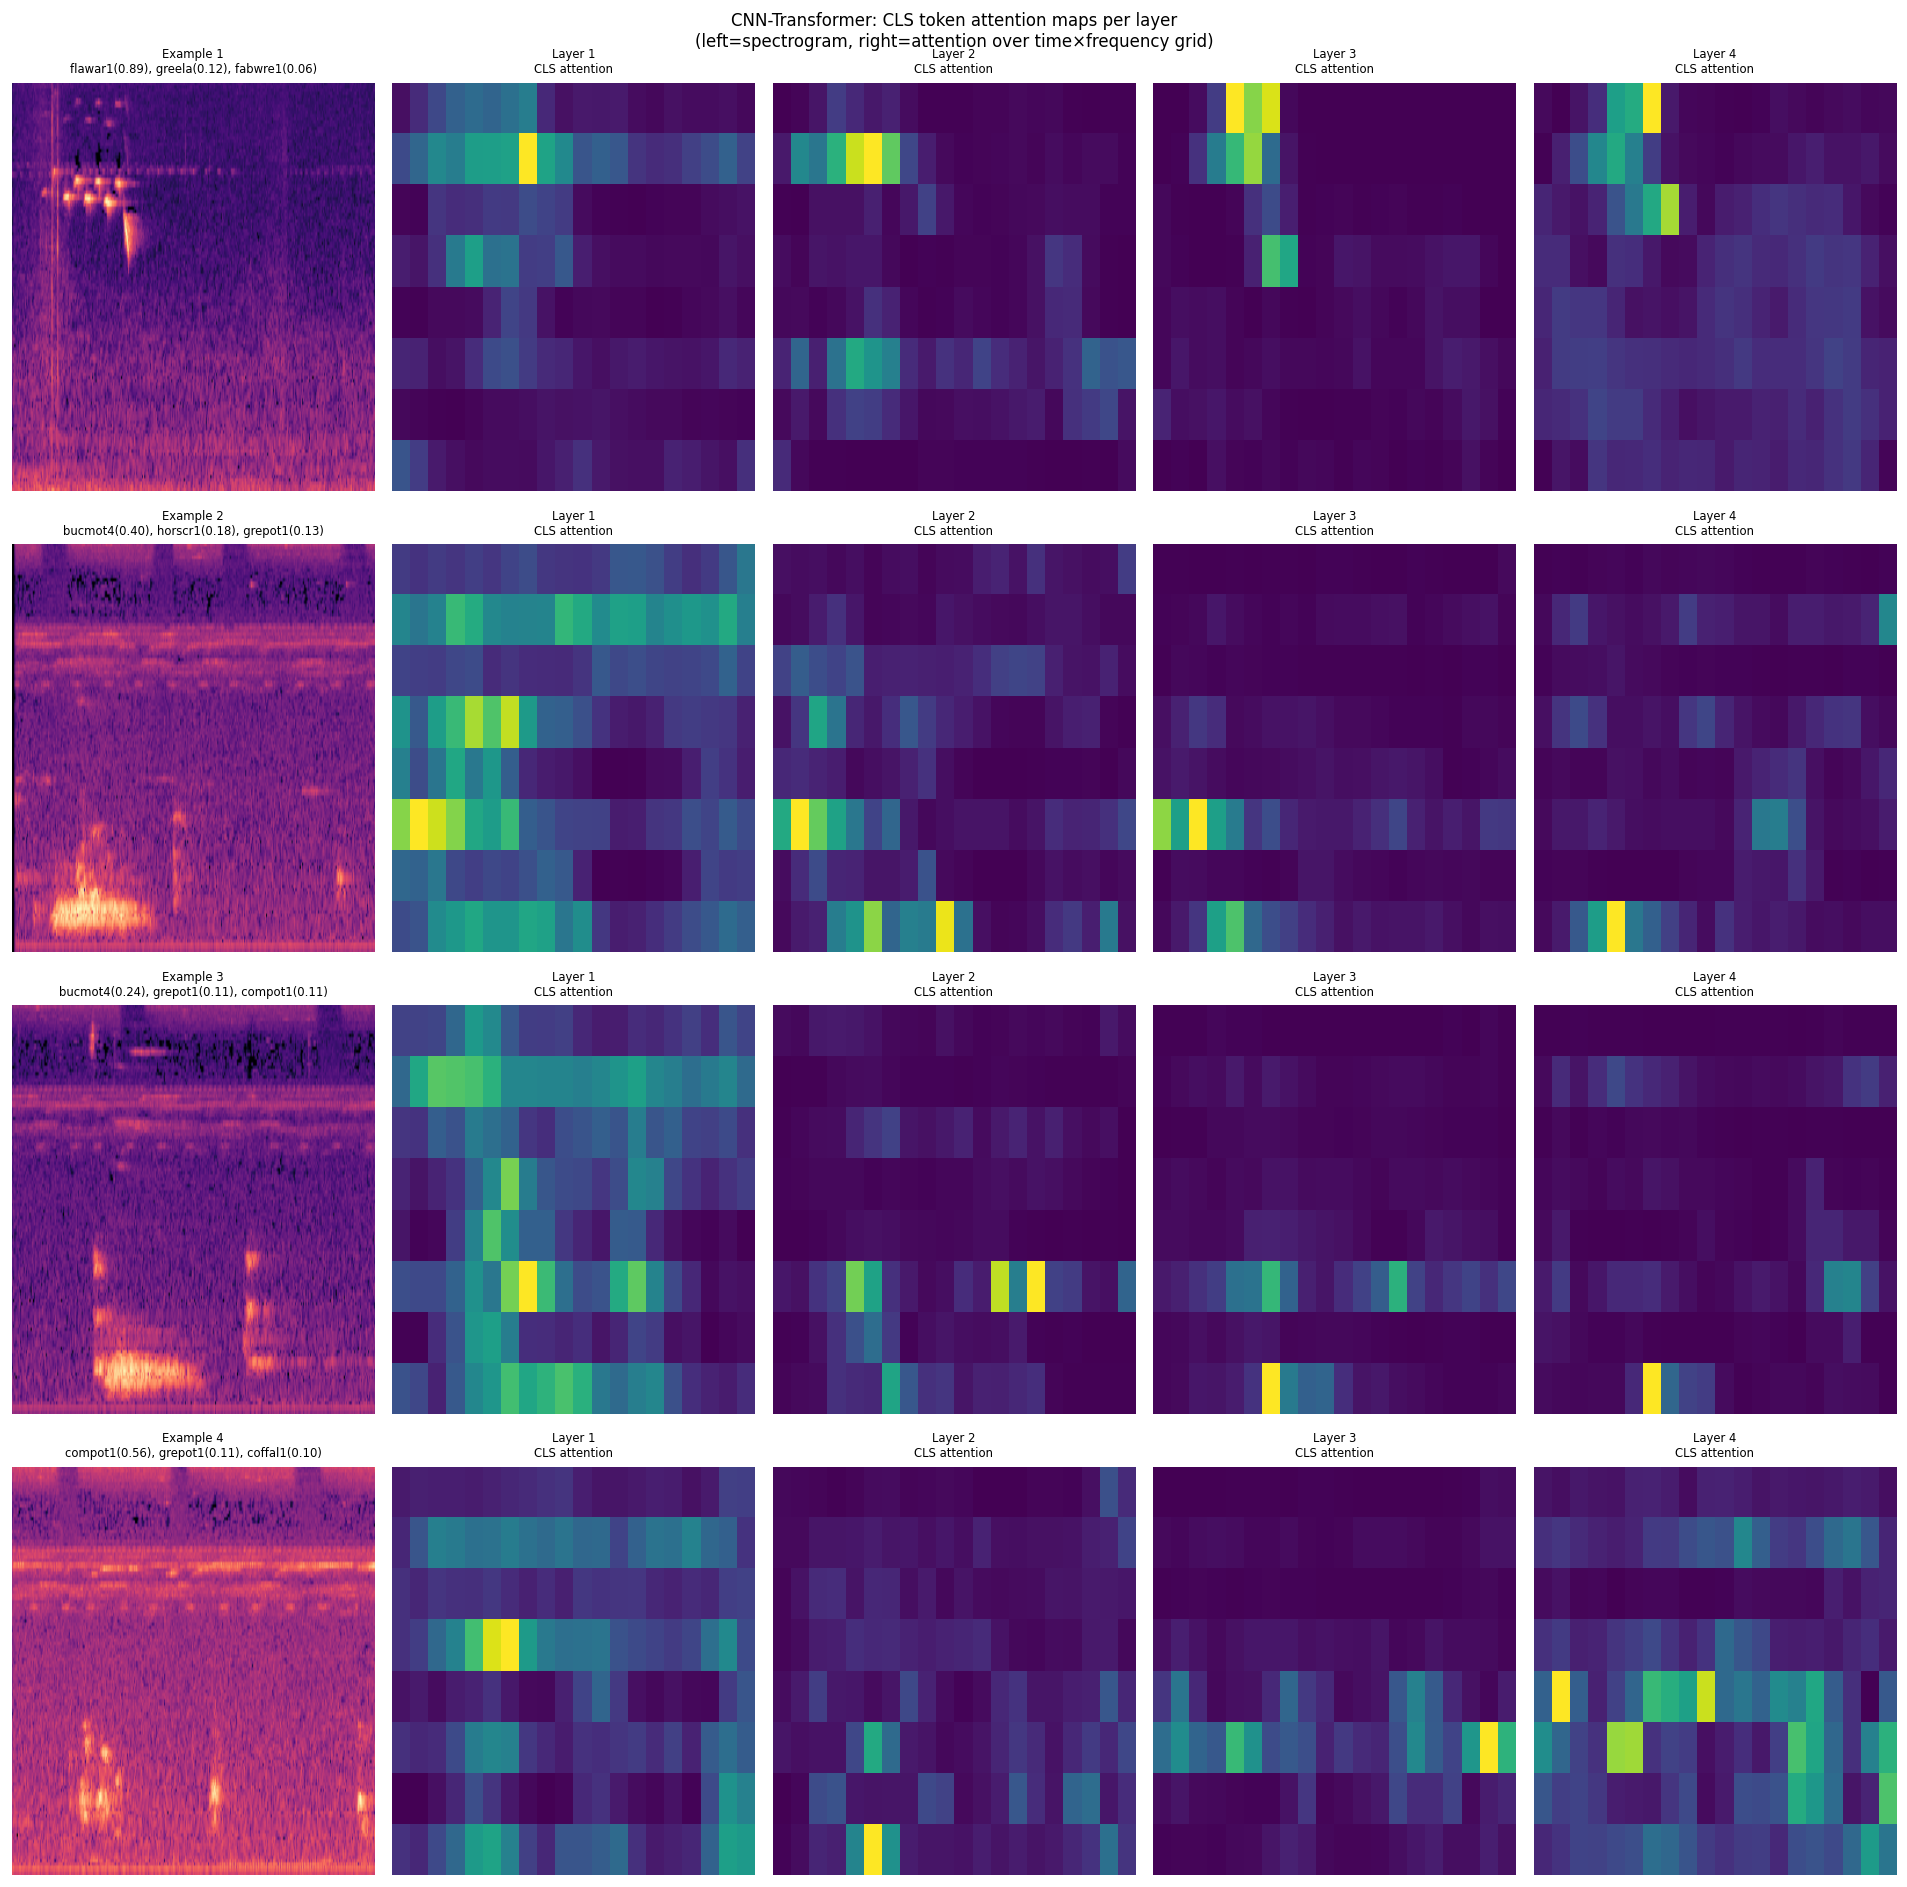

In [13]:
if CKPT_PATH.exists() and attn_weights_list:
    # Get CNN output shape to reconstruct 2D attention grid
    with torch.no_grad():
        dummy = torch.zeros(1, 1, 128, 313)
        feat  = model.cnn(dummy)[0]
    _, _, H, W = feat.shape
    print(f'CNN feature map: H={H}, W={W}, tokens={H*W} + 1 CLS')

    N_EXAMPLES = min(4, specs_batch.shape[0])
    N_LAYERS   = len(attn_weights_list)

    fig = plt.figure(figsize=(16, N_EXAMPLES * 4))
    gs  = gridspec.GridSpec(N_EXAMPLES, N_LAYERS + 1, figure=fig)

    for ex in range(N_EXAMPLES):
        # Plot spectrogram
        ax_spec = fig.add_subplot(gs[ex, 0])
        ax_spec.imshow(specs_batch[ex, 0].numpy(), aspect='auto',
                       origin='lower', cmap='magma')
        # Show predicted species
        with torch.no_grad():
            logits = model(specs_batch[ex:ex+1])
            probs  = torch.sigmoid(logits)[0]
        top3_idx  = probs.topk(3).indices.tolist()
        top3_info = ', '.join([f'{mlb.classes_[i]}({probs[i]:.2f})' for i in top3_idx])
        ax_spec.set_title(f'Example {ex+1}\n{top3_info}', fontsize=7)
        ax_spec.axis('off')

        # Plot attention from CLS token for each layer
        for layer_idx, attn in enumerate(attn_weights_list):
            # attn: (B, seq_len, seq_len); row 0 = CLS attending to all tokens
            cls_attn = attn[ex, 0, 1:].numpy()  # skip CLS self-attention
            attn_2d  = cls_attn.reshape(H, W)
            ax = fig.add_subplot(gs[ex, layer_idx + 1])
            ax.imshow(attn_2d, aspect='auto', origin='lower', cmap='viridis')
            ax.set_title(f'Layer {layer_idx+1}\nCLS attention', fontsize=7)
            ax.axis('off')

    fig.suptitle('CNN-Transformer: CLS token attention maps per layer\n'
                 '(left=spectrogram, right=attention over time×frequency grid)',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_attention_maps.png', dpi=150)
    plt.show()
else:
    print('Skipped — checkpoint not loaded or no attention weights captured.')

**Example 1** (*flawar1* - Flamingo):
The bright spots in layers 1-2 appear in the upper-left region of the time-frequency grid, which corresponds to lower frequencies in the early part of the clip. Looking at the spectrogram, there's a clear concentrated energy pattern in that region. The attention becomes more sparse and focused by layers 3-4, which is typical; early layers attend broadly, later layers focus on the most discriminative regions.

**Example 2** (*bucmot4* - Blue-crowned Motmot):
More interesting, there are two distinct bright regions, one in the middle and one at the bottom of the grid. The bottom attention corresponds to the very bright low-frequency burst visible at the bottom of the spectrogram. The model is correctly attending to the most energetic part of the call. The attention pattern also shifts across layers, suggesting the Transformer is doing some meaningful refinement.

**What this tells us about the Transformer:**
The attention maps are not uniform, the model is genuinely attending to specific time-frequency regions rather than spreading attention evenly. This is evidence that the Transformer is actually learning something meaningful, even if the AUC gain over the CNN baseline is modest. The low-resolution of the attention grid (only 8×10 cells with num_cnn_blocks=4) limits how precise the attention can be though, this is a direct consequence of the aggressive downsampling.

### 3.4 Attention visualisation — Pretrained ViT

In [15]:
import torch.nn.functional as F

CKPT_VIT = OUTPUT_DIR / 'best_pretrained_transformer__final_seed42.pt'

if not CKPT_VIT.exists():
    print(f'Checkpoint not found: {CKPT_VIT}')
else:
    ckpt_vit  = torch.load(CKPT_VIT, map_location='cpu')
    kwargs_vit = ckpt_vit.get('model_kwargs', {})
    vit_model  = load_model('pretrained_transformer', ckpt_vit['num_classes'], **kwargs_vit)

    # Strip _orig_mod. prefix added by torch.compile
    state_dict_vit = ckpt_vit['model_state']
    state_dict_vit = {
        k.replace('_orig_mod.', ''): v 
        for k, v in state_dict_vit.items()
    }
    
    vit_model.load_state_dict(state_dict_vit)
    vit_model.eval()
    print('Loaded pretrained_transformer')

    vit_attn_list = []
    vit_hooks = []
    
    for block in vit_model.vit.blocks:
        # Disable fused attention — timm uses fused_attn by default which
        # doesn't return attention weights
        block.attn.fused_attn = False
        
        def _vit_attn_hook(module, input, output):
            # With fused_attn=False, timm's Attention.forward returns
            # just the output tensor, but we can access weights via
            # a second hook on the softmax operation
            pass
        
        # Instead hook the attn_drop to capture post-softmax weights
        def make_hook():
            def hook(module, input, output):
                vit_attn_list.append(output.detach())
            return hook
        
        h = block.attn.attn_drop.register_forward_hook(make_hook())
        vit_hooks.append(h)
    
    padded = F.pad(specs_batch, (0, 7))
    with torch.no_grad():
        _ = vit_model.vit(padded)
    
    for h in vit_hooks:
        h.remove()
    
    print(f'Captured {len(vit_attn_list)} attention layers from pretrained ViT')
    if vit_attn_list:
        print(f'Attention shape (layer 0): {vit_attn_list[0].shape}')

Loaded pretrained_transformer
Captured 12 attention layers from pretrained ViT
Attention shape (layer 0): torch.Size([8, 6, 161, 161])


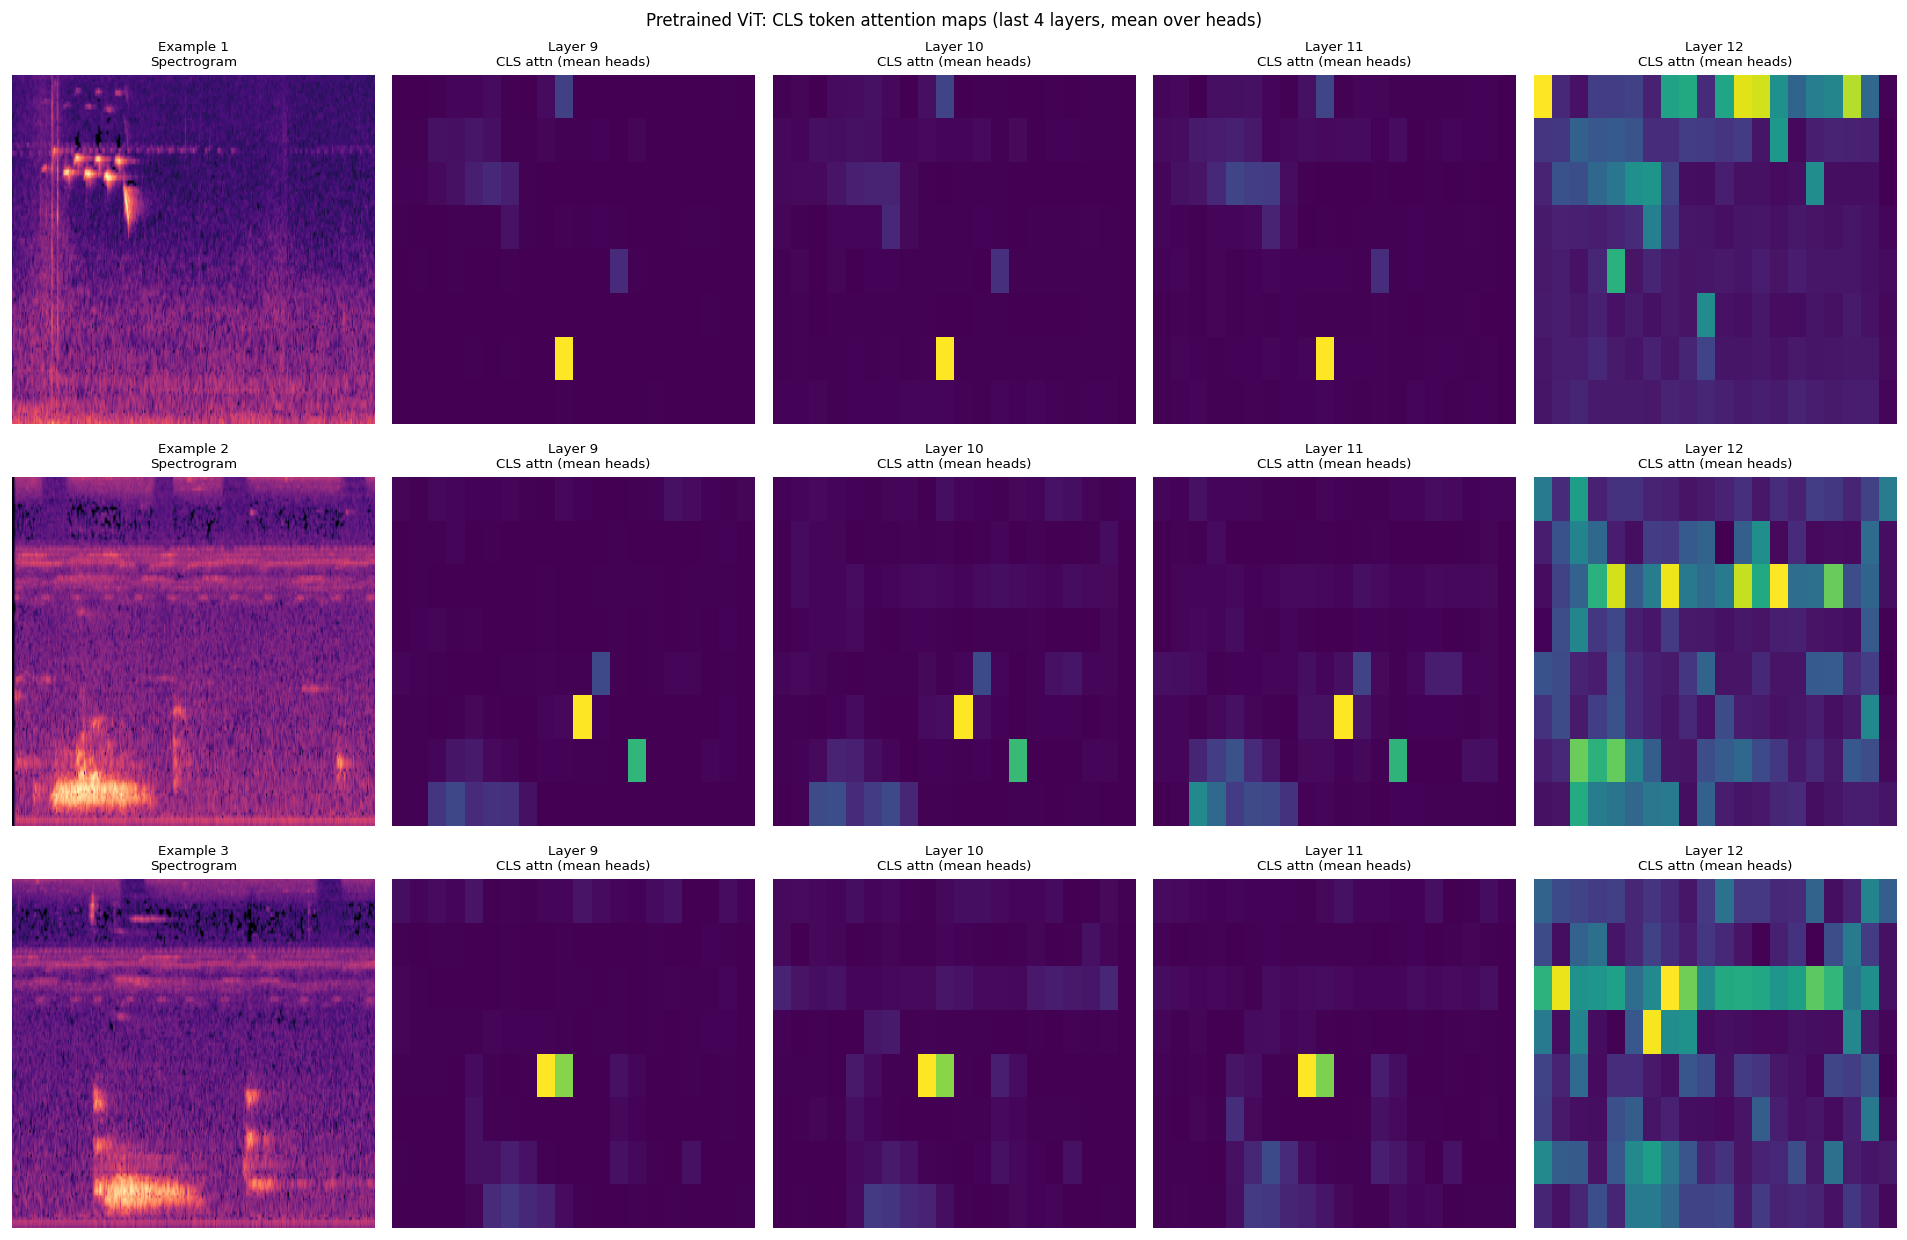

In [16]:
if CKPT_VIT.exists() and vit_attn_list:
    # ViT-Small/16 on (128, 320): patch grid = 8×20 = 160 tokens
    H_vit, W_vit = 8, 20
    # Show last 4 layers (most task-relevant)
    layers_to_show = vit_attn_list[-4:]
    N_EXAMPLES = min(3, specs_batch.shape[0])

    fig, axes = plt.subplots(N_EXAMPLES, len(layers_to_show) + 1,
                             figsize=(16, N_EXAMPLES * 3.5))
    if N_EXAMPLES == 1:
        axes = axes[np.newaxis, :]

    for ex in range(N_EXAMPLES):
        axes[ex, 0].imshow(specs_batch[ex, 0].numpy(),
                           aspect='auto', origin='lower', cmap='magma')
        axes[ex, 0].set_title(f'Example {ex+1}\nSpectrogram', fontsize=8)
        axes[ex, 0].axis('off')

        for li, attn in enumerate(layers_to_show):
            # attn: (B, n_heads, seq_len, seq_len)
            # Average heads, take CLS row, skip CLS self-attention
            cls_attn = attn[ex].mean(0)[0, 1:].numpy()
            attn_2d  = cls_attn[:H_vit * W_vit].reshape(H_vit, W_vit)
            axes[ex, li + 1].imshow(attn_2d, aspect='auto',
                                     origin='lower', cmap='viridis')
            layer_num = len(vit_attn_list) - len(layers_to_show) + li + 1
            axes[ex, li + 1].set_title(f'Layer {layer_num}\nCLS attn (mean heads)', fontsize=8)
            axes[ex, li + 1].axis('off')

    fig.suptitle('Pretrained ViT: CLS token attention maps (last 4 layers, mean over heads)',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_vit_attention_maps.png', dpi=150)
    plt.show()
else:
    print('Skipped — checkpoint not loaded or no attention weights captured.')

The pretrained ViT attention maps reveal a distinctly different attention strategy compared to the CNN-Transformer, reflecting the fundamental architectural difference between the two models.

**Sparse, highly concentrated attention in intermediate layers:** Layers 9-11 show extremely sharp attention patterns, one or two bright spots against a nearly black background. This is characteristic of a mature, well-trained Transformer that has learned to identify the single most discriminative time-frequency region for each species and ignore everything else. Rather than being a weakness, this sparsity is evidence of confident, specialised feature selection driven by ImageNet pretraining, which provides strong prior knowledge about which visual patterns are informative.

**Broad aggregation in the final layer:** Layer 12 consistently spreads attention across many tokens in both examples, in stark contrast to the focused patterns of earlier layers. This is a well-documented behaviour in deep Transformers. Intermediate layers perform selective feature detection while the final layer aggregates global context into the CLS token for classification. The transition from sparse to broad attention between layer 11 and layer 12 is particularly clear here.

**Frequency specificity:** Despite the sparsity, the attention spots are not random, they correspond to specific frequency bands visible in the spectrograms. In Example 1, the bright spot sits consistently in the lower-mid frequency range across layers 9-11, matching the concentrated energy pattern in that region of the spectrogram. In Example 2, two distinct spots appear at different frequency bands, corresponding to the two separate energy bursts visible in the spectrogram. This demonstrates that the pretrained ViT is attending to acoustically meaningful regions despite having no explicit frequency-aware inductive bias.

**Comparison with the CNN-Transformer:** The CNN-Transformer showed more distributed attention across multiple regions simultaneously, likely because its CNN front-end already handles local feature detection, leaving the Transformer to perform broader spatial reasoning. The pretrained ViT, by contrast, must handle both local and global reasoning within the Transformer itself, leading to the more extreme sparsity observed in intermediate layers. Both strategies arrive at strong classification performance, but through different mechanisms (selective sparsity in the pretrained ViT versus distributed spatial reasoning in the CNN-Transformer).

---
## Summary of saved figures

| File | Contents |
|---|---|
| `fig_learning_curves_5s_zoomed.png` | val_AUC per epoch, all models, 3 seeds zoomed in range 0.25-0.2|
| `fig_learning_curves_5s.png` | val_AUC per epoch, all models, 3 seeds |
| `fig_train_loss_5s.png` | Train loss per epoch, all models |
| `fig_5s_vs_10s.png` | 5s vs 10s val_AUC per epoch, per model |
| `fig_model_comparison.png` | Bar chart — best val_AUC with seed variance |
| `fig_per_class_auc_dist.png` | Histogram of per-class AUC across species |
| `fig_hardest_easiest_species.png` | 15 hardest and easiest species by AUC of Pretrained ViT|
| `fig_hardest_easiest_species_CNN_Transformer.png` | 15 hardest and easiest species by AUC of CNN Transformer|
| `fig_hard_species_comparison.png` | Per-class AUC for hardest species across models |
| `fig_attention_maps.png` | CNN-Transformer CLS attention maps |
| `fig_vit_attention_maps.png` | Pretrained ViT CLS attention maps |